# ЛЗ 6. ENUWay жобасының мерзімін ықтималдықпен болжау

**Мақсат:** 18 элементтен тұратын backlog аяқталу мерзімін бір күнмен емес,
ықтималдық диапазонымен бағалау.

**Тарихи дерек:** ашық [Pallets Click issues тізімі](https://github.com/pallets/click/issues?q=is%3Aissue%20is%3Aclosed%20closed%3A2026-04-06..2026-10-04),
06.04.2026–04.10.2026 аралығындағы 26 толық апта. Қаралған күні: **08.10.2026**.
Экспортта 106 жабылған issue бар, pull request есепке алынбады.

ENUWay командасында алты аптаға жететін жеке тарих әлі жоқ. Сондықтан Click деректері
сыртқы proxy ретінде қолданылды. Бұл шектеу қорытындыда ескерілді. Нөлдік апталар
мереке, ауру немесе блоктау ықпалын сақтайтындықтан деректен алынған жоқ.

**Модель:** 10 000 симуляция, тұрақты seed `20261008`, бастапқы күн `08.10.2026`.

In [1]:
from pathlib import Path
from datetime import date, timedelta
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20261008
RUNS = 10_000
BACKLOG_ITEMS = 18
FORECAST_START = date(2026, 10, 8)

candidates = [Path.cwd(), Path.cwd() / "notebooks" / "lz6"]
BASE = next((path for path in candidates if (path / "data" / "throughput.csv").exists()), None)
assert BASE is not None, "Notebook-ті notebooks/lz6 бумасынан немесе репозиторий түбірінен іске қосыңыз"
DATA = BASE / "data"
FIGURES = BASE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#1F4E78"
ORANGE = "#E07A3F"
BASE

WindowsPath('C:/Users/L/Documents/ChatGPT/Управление IT-проектами/ENUWay-repo/notebooks/lz6')

## 1. Тарихи throughput деректері

In [2]:
history = pd.read_csv(DATA / "throughput.csv", parse_dates=["week_start", "week_end"])
source = json.loads((DATA / "source.json").read_text(encoding="utf-8"))
throughput = history["throughput_items"].to_numpy(dtype=int)

assert len(history) == 26
assert throughput.sum() == source["closed_issues"] == 106
assert (throughput == 0).sum() == 3

summary = pd.Series({
    "Апта саны": len(throughput),
    "Жабылған issue саны": int(throughput.sum()),
    "Орташа throughput": throughput.mean(),
    "Медиана": np.median(throughput),
    "Минимум": throughput.min(),
    "Максимум": throughput.max(),
    "Нөлдік апта саны": int((throughput == 0).sum()),
})
display(summary.to_frame("Мәні").round(2))
display(history)

,Мәні
Апта саны,26.00
Жабылған issue саны,106.00
Орташа throughput,4.08
Медиана,3.00
Минимум,0.00
Максимум,16.00
Нөлдік апта саны,3.00


,week_start,week_end,throughput_items
0,2026-04-06,2026-04-12,3
1,2026-04-13,2026-04-19,9
2,2026-04-20,2026-04-26,1
3,2026-04-27,2026-05-03,8
4,2026-05-04,2026-05-10,3
5,2026-05-11,2026-05-17,8
6,2026-05-18,2026-05-24,16
7,2026-05-25,2026-05-31,9
8,2026-06-01,2026-06-07,2
9,2026-06-08,2026-06-14,4


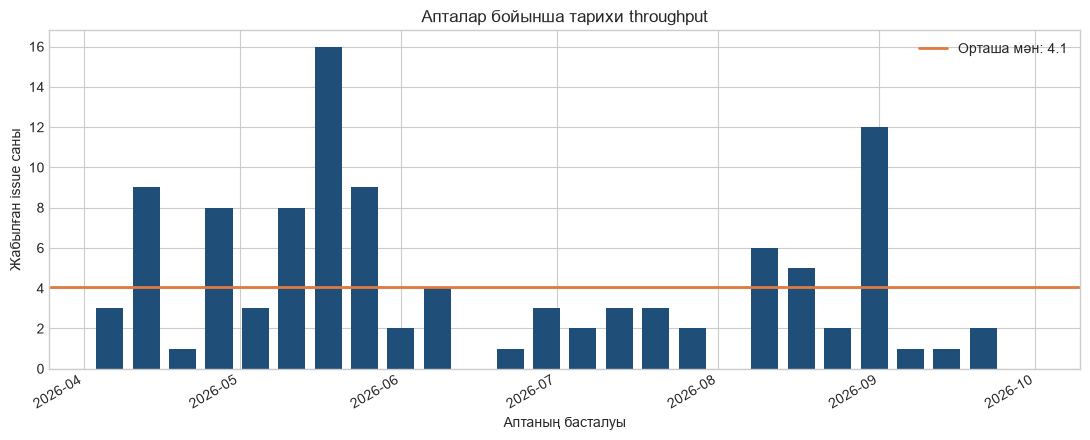

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(history["week_start"], throughput, width=5.2, color=BLUE)
ax.axhline(throughput.mean(), color=ORANGE, linewidth=2,
           label=f"Орташа мән: {throughput.mean():.1f}")
ax.set(title="Апталар бойынша тарихи throughput",
       xlabel="Аптаның басталуы", ylabel="Жабылған issue саны")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "historical-throughput.png", dpi=180, bbox_inches="tight")
plt.show()

**График бойынша қорытынды:** апталық нәтиже 0 мен 16 элемент аралығында өзгерген.
Үш нөлдік апта сақталды. Сондықтан тек орташа 4,08 элементке сүйену тәуекелді
төмен көрсетеді және ықтималдық симуляциясы қажет.

## 2. Монте-Карло симуляциясы

In [4]:
def simulate(backlog_items, runs=RUNS, seed=SEED):
    rng = np.random.default_rng(seed)
    result = np.empty(runs, dtype=int)
    for run in range(runs):
        completed = 0
        weeks = 0
        while completed < backlog_items:
            completed += int(rng.choice(throughput))
            weeks += 1
            if weeks > 520:
                raise RuntimeError("Симуляция аяқталмады")
        result[run] = weeks
    return result

weeks_to_finish = simulate(BACKLOG_ITEMS)
percentile_levels = [50, 70, 85, 95]
percentile_weeks = {
    p: int(np.quantile(weeks_to_finish, p / 100, method="higher"))
    for p in percentile_levels
}
percentile_dates = {
    p: FORECAST_START + timedelta(weeks=weeks)
    for p, weeks in percentile_weeks.items()
}

forecast = pd.DataFrame({
    "Осы күнге дейін аяқтау ықтималдығы": [f"P{p}" for p in percentile_levels],
    "Апта саны": [percentile_weeks[p] for p in percentile_levels],
    "Күні": [percentile_dates[p].strftime("%d.%m.%Y") for p in percentile_levels],
})
display(forecast)
forecast.to_csv(BASE / "forecast-summary.csv", index=False, encoding="utf-8-sig")

,Осы күнге дейін аяқтау ықтималдығы,Апта саны,Күні
0,P50,5,12.11.2026
1,P70,6,19.11.2026
2,P85,7,26.11.2026
3,P95,9,10.12.2026


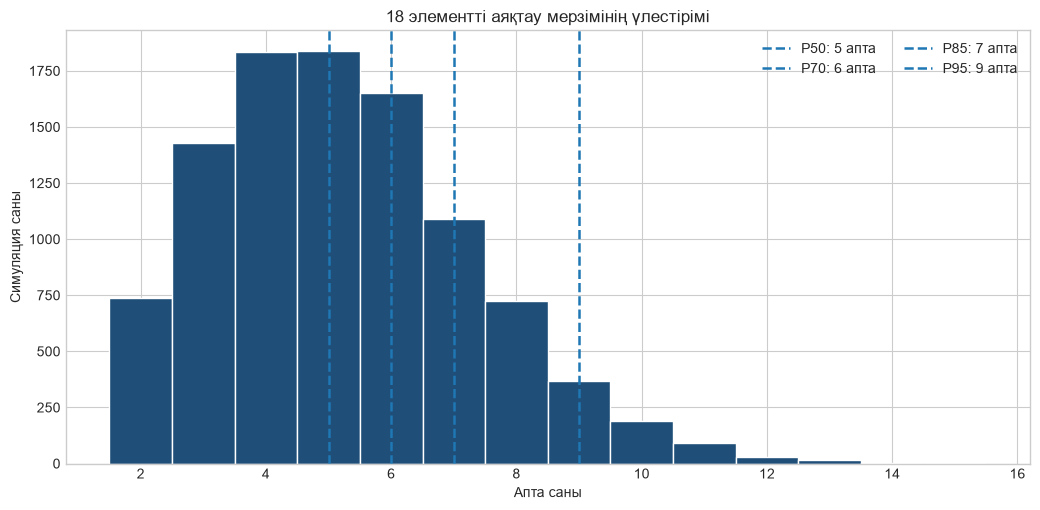

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bins = np.arange(weeks_to_finish.min() - 0.5, weeks_to_finish.max() + 1.5, 1)
ax.hist(weeks_to_finish, bins=bins, color=BLUE, edgecolor="white")
for p in percentile_levels:
    ax.axvline(percentile_weeks[p], linestyle="--", linewidth=1.8,
               label=f"P{p}: {percentile_weeks[p]} апта")
ax.set(title="18 элементті аяқтау мерзімінің үлестірімі",
       xlabel="Апта саны", ylabel="Симуляция саны")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "completion-histogram.png", dpi=180, bbox_inches="tight")
plt.show()

**Гистограмма бойынша қорытынды:** ең жиі сценарийлер 4–6 аптада шоғырланған,
бірақ нөлдік және төмен throughput апталарынан оң жақ құйрық пайда болады.
Сол себепті бір ғана «орташа күн» кешігу тәуекелін көрсетпейді.

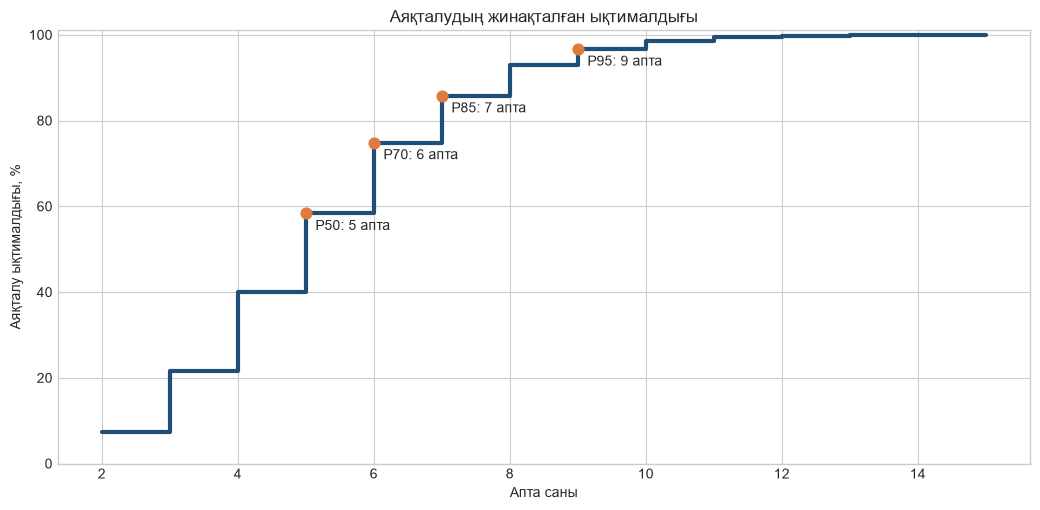

In [6]:
values, counts = np.unique(weeks_to_finish, return_counts=True)
cdf = np.cumsum(counts) / RUNS
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.step(values, cdf * 100, where="post", color=BLUE, linewidth=3)
for p in percentile_levels:
    week = percentile_weeks[p]
    actual_probability = cdf[np.where(values == week)[0][0]] * 100
    ax.scatter(week, actual_probability, s=60, color=ORANGE, zorder=3)
    ax.annotate(f"P{p}: {week} апта", (week, actual_probability),
                xytext=(7, -12), textcoords="offset points")
ax.set(title="Аяқталудың жинақталған ықтималдығы",
       xlabel="Апта саны", ylabel="Аяқталу ықтималдығы, %", ylim=(0, 101))
fig.tight_layout()
fig.savefig(FIGURES / "completion-cdf.png", dpi=180, bbox_inches="tight")
plt.show()

**Жинақталған қисық бойынша қорытынды:** тапсырыс беруші тәуекелге қарай мерзімді
таңдай алады. 12.11.2026 күніне дейін аяқтау ықтималдығы кемінде 50%, ал
26.11.2026 күніне дейін кемінде 85%. Команда міндеттеме үшін 85% деңгейін ұсынады.

## 3. Story points бойынша детерминделген бағамен салыстыру

In [7]:
REPO_ROOT = BASE.parents[1]
backlog = pd.read_csv(REPO_ROOT / "docs" / "requirements" / "backlog.csv")
poker = pd.read_csv(REPO_ROOT / "docs" / "forecast" / "planning-poker.csv")

original_sp = int(backlog["Story Points"].sum())
original_first_ten = int(backlog.iloc[:10]["Story Points"].sum())
revised_first_ten = int(poker["Келісілген SP"].sum())
revised_total_sp = original_sp - original_first_ten + revised_first_ten

# Допущение: бұл нақты velocity тарихы емес, planning poker кезінде команда ұсынған жоспарлы қарқын.
ASSUMED_VELOCITY = 14
deterministic_weeks = math.ceil(revised_total_sp / ASSUMED_VELOCITY)
deterministic_date = FORECAST_START + timedelta(weeks=deterministic_weeks)

comparison = pd.DataFrame([
    ["Story points", revised_total_sp, deterministic_weeks,
     deterministic_date.strftime("%d.%m.%Y"), "Ықтималдық көрсетілмейді"],
    ["Монте-Карло P50", BACKLOG_ITEMS, percentile_weeks[50],
     percentile_dates[50].strftime("%d.%m.%Y"), "50%"],
    ["Монте-Карло P85", BACKLOG_ITEMS, percentile_weeks[85],
     percentile_dates[85].strftime("%d.%m.%Y"), "85%"],
    ["Монте-Карло P95", BACKLOG_ITEMS, percentile_weeks[95],
     percentile_dates[95].strftime("%d.%m.%Y"), "95%"],
], columns=["Әдіс", "Көлем", "Апта саны", "Күні", "Сенімділік"])
display(comparison)
print(f"Planning poker-ден кейін баға {original_sp} SP-ден {revised_total_sp} SP-ге өсті.")
print(f"Допущение: жоспарлы velocity = {ASSUMED_VELOCITY} SP/апта; тарихи velocity әлі жоқ.")

,Әдіс,Көлем,Апта саны,Күні,Сенімділік
0,Story points,75,6,19.11.2026,Ықтималдық көрсетілмейді
1,Монте-Карло P50,18,5,12.11.2026,50%
2,Монте-Карло P85,18,7,26.11.2026,85%
3,Монте-Карло P95,18,9,10.12.2026,95%


Planning poker-ден кейін баға 69 SP-ден 75 SP-ге өсті.
Допущение: жоспарлы velocity = 14 SP/апта; тарихи velocity әлі жоқ.


**Айырмашылықтың түсіндірмесі:** story points тарихтардың салыстырмалы күрделілігін,
ал throughput аяқталған элементтер санын өлшейді. Детерминделген есеп тұрақты
14 SP/апта деген допущениеге сүйенеді, нашар апталарды және өзгергіштікті есептемейді.
Орташа мәнге бөлу аяқталу ықтималдығын бермейді. Сондықтан 19.11.2026 күні
детерминделген жоспар ретінде көрінгенімен, Монте-Карло бойынша ол тек P70 деңгейіне сәйкес.

## 4. Он тарих бойынша planning poker хаттамасы

In [8]:
display(poker)
votes = poker[["1-қатысушы", "2-қатысушы", "3-қатысушы"]]
spread = votes.max(axis=1) - votes.min(axis=1)
poker_summary = pd.DataFrame({
    "Тарих саны": [len(poker)],
    "Бірінші раундта айырмасы бар тарих": [int((spread > 0).sum())],
    "Ең үлкен айырма": [int(spread.max())],
    "Келісілген SP сомасы": [int(poker["Келісілген SP"].sum())],
})
display(poker_summary)

,ID,Пайдаланушы тарихы,1-қатысушы,2-қатысушы,3-қатысушы,Бірінші раунд айырмасы,Келісілген SP,Айырмашылық себебі,Нақтыланған қабылдау критерийі
0,US-01,ENU аккаунтымен тіркелу,3,5,8,5,5,ENU доменін тексеру және теріс сценарий әртүрл...,ENU доменіне жатпайтын пошта 403 қатесімен қаб...
1,US-02,Профильді толтыру,2,3,3,1,3,Міндетті өрістер мен құпиялық тексеруі нақтыланды,Телефон міндетті емес және басқа пайдаланушыға...
2,US-03,Бағыт пен күн бойынша іздеу,3,5,8,5,5,"Сүзгілер, сұрыптау және бос нәтиже күйі толық ...",Нәтиже болмаса бос күй және сүзгіні тазарту әр...
3,US-04,Сапар карточкасын көру,3,3,5,2,3,Деректер құрамы мен жабық сапар күйі талқыланды,Жабық сапарда қосылу батырмасы белсенді болмайды
4,US-05,Жаңа сапар құру,5,8,8,3,8,"Draft күйі, валидация және жариялау ережесі жа...",Қате өрістер түзетілмейінше сапар жарияланбайд...
5,US-06,Орын санын белгілеу,1,2,3,2,2,Шекаралық мәндер мен орын санының өзгеруі нақт...,Орын саны 1–4 аралығында ғана қабылданады
6,US-07,Шығын үлесін көрсету,1,2,3,2,2,Сома диапазоны мен көрсету форматы әртүрлі бағ...,Сома теңгемен және 0–5000 аралығында көрсетіледі
7,US-08,Қосылу сұрауын жіберу,3,5,8,5,5,Бос орынды бір уақытта өзгерту және хабарлама ...,Бос орын қалмаса қатар келген екінші сұрау қаб...
8,US-09,Сұрауды қабылдау немесе қабылдамау,5,8,13,8,8,"Қайталанған шешім, орын саны және race conditi...",Бір сұрауға қайталама шешім берілмейді және ор...
9,US-10,Менің сапарларым,2,3,5,3,3,Алдағы және өткен сапарларды топтау ережесі на...,Сапарлар алдағы және өткен болып бөлініп күн б...


,Тарих саны,Бірінші раундта айырмасы бар тарих,Ең үлкен айырма,Келісілген SP сомасы
0,10,10,8,44


**Покер қорытындысы:** үш қатысушы Фибоначчи шкаласын қолданып, бірінші дауысты
бір мезгілде ашты. Ең үлкен айырма US-09 тарихында болды. Талқылау кезінде команда
қайталама шешім, орын санын атомарлы өзгерту және қатар орындалатын сұрауларды
нақтылады. Барлық 10 тарихтың қабылдау критерийіне анықталған шекаралар қосылды.
Толық себеп пен өзгерген критерий `docs/forecast/planning-poker.csv` файлында берілген.

## 5. Жоспарға енгізілген өзгеріс

In [9]:
reduced_items = 14
reduced_weeks = simulate(reduced_items)
reduced_p85_weeks = int(np.quantile(reduced_weeks, 0.85, method="higher"))
reduced_p85_date = FORECAST_START + timedelta(weeks=reduced_p85_weeks)

decision = pd.DataFrame([
    ["Толық backlog", 18, percentile_weeks[85], percentile_dates[85].strftime("%d.%m.%Y")],
    ["US-13–US-16 келесі релизге ауысады", 14, reduced_p85_weeks,
     reduced_p85_date.strftime("%d.%m.%Y")],
], columns=["Сценарий", "Элемент саны", "85% деңгейіндегі апта", "Күні"])
display(decision)

,Сценарий,Элемент саны,85% деңгейіндегі апта,Күні
0,Толық backlog,18,7,26.11.2026
1,US-13–US-16 келесі релизге ауысады,14,6,19.11.2026


**Тапсырыс берушіге ұсыныс:** толық 18 элемент сақталса, команда 26.11.2026 күнін
85% сенімділікпен ұсынады. Егер 19.11.2026 міндетті шек болса, рейтинг, шағым,
бұғаттау және модерация тарихтарын (US-13–US-16) келесі релизге ауыстырамыз.
Сонда 14 элементті 19.11.2026 дейін аяқтау ықтималдығы кемінде 85% болады.

Болжам backlog көлемі, команда құрамы, сыртқы блоктаушылар немесе апталық throughput
өзгерсе қайта есептеледі. Келесі жоспарлы қайта есептеу күні: **22.10.2026**.

## 6. Қолданылған құралдар туралы ашықтық

OpenAI Codex notebook құрылымын, Python кодының бастапқы нұсқасын және мәтін
формулировкаларын дайындауға қолданылды. Команда дереккөзді, есептеу параметрлерін,
нәтижелерді және қорытындыларды тексеруге жауапты.